# EDA — Predicción de reingreso hospitalario en pacientes diabéticos

**Repositorio:** `github.com/mzc07/diabetes-readmission-predictor` (rama `develop`)
**Autores:** Martín Ariza (2251516) - Ivanna Alvarez (2251805) - Juliana Rueda (2251801)
**Entorno:** Google Colab

Este notebook ejecuta el pipeline de análisis exploratorio de datos (EDA) definido en
`src/data/` (carga y calidad) y `src/eda/` (univariado, bivariado, relevancia), y
visualiza e interpreta cada resultado.

## Marco conceptual

El EDA, no busca confirmar una hipótesis fija sino **generar
hipótesis** y entender la estructura de los datos antes de modelar. Este notebook sigue
una secuencia donde cada etapa depende de la anterior:

1. **Calidad de datos** — ¿son confiables los datos? (faltantes, duplicados, valores imposibles)
2. **Univariado** — ¿cómo se comporta cada variable por separado?
3. **Bivariado** — ¿cómo se relaciona cada variable con el target?
4. **Relevancia** — ¿qué variables tienen más señal predictiva?

No tiene sentido interpretar una correlación bivariada sin haber visto antes qué tan
confiable es esa columna, ni rankear relevancia sin conocer la forma de cada distribución,
porque esa forma determina qué test estadístico es válido usar en cada caso.


## 1. Configuración del entorno en Colab

In [ ]:
# Clona el repositorio (rama develop) para tener acceso a src/data y src/eda
!git clone --branch develop --single-branch https://github.com/mzc07/diabetes-readmission-predictor.git
%cd diabetes-readmission-predictor


fatal: destination path 'diabetes-readmission-predictor' already exists and is not an empty directory.
/content/diabetes-readmission-predictor/diabetes-readmission-predictor


In [ ]:
!pip install -q pandas scipy scikit-learn matplotlib seaborn


In [ ]:
import sys
sys.path.append(".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_diabetic_data, load_id_mappings, validate_schema
from src.data.quality import (
    missing_value_report,
    duplicate_report,
    sentinel_value_scan,
    numeric_out_of_range_report,
)
from src.eda.univariate import numeric_summary, categorical_summary, target_distribution
from src.eda.bivariate import (
    correlation_matrix,
    high_correlation_pairs,
    categorical_vs_target_chi2,
    numeric_vs_target_test,
)
from src.eda.relevance import mutual_info_ranking, cramers_v_ranking

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 2. Carga de datos

Sube `diabetic_data.csv` e `IDS_mapping.csv` a la sesión de Colab (panel de archivos,
ícono de carpeta a la izquierda), o móntalos desde Google Drive. Ajusta las rutas si es
necesario.


In [ ]:
from google.colab import files

# Si los archivos no están ya en el entorno, descomenta para subirlos manualmente:
# uploaded = files.upload()

DATA_PATH = "/content/diabetes-readmission-predictor/data/raw/diabetic_data.csv"
IDS_PATH = "/content/diabetes-readmission-predictor/data/raw/IDS_mapping.csv"


In [ ]:
df = load_diabetic_data(DATA_PATH, treat_sentinels_as_na=True)
id_mappings = load_id_mappings(IDS_PATH)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


Filas: 101,766 | Columnas: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Interpretación:** `load_diabetic_data` reemplaza centinelas (`"?"`, `"Not Available"`,
etc.) por `NaN` real, pero solo en columnas donde eso es correcto semánticamente
(`race`, `weight`, `payer_code`, `medical_specialty`, `diag_1/2/3`). `load_id_mappings`
separa las tablas de códigos concatenadas en `IDS_mapping.csv` (ej. `admission_type_id`
→ descripción), útiles para traducir códigos numéricos en el resto del análisis.


In [ ]:
problems = validate_schema(df)
if problems:
    print("Problemas de esquema encontrados:")
    for p in problems:
        print(" -", p)
else:
    print("Esquema válido: sin problemas detectados.")


Esquema válido: sin problemas detectados.


**Cómo leer esto:** si la lista sale vacía, las columnas clave existen, no hay nulos
en los identificadores (`encounter_id`, `patient_nbr`), no hay `encounter_id` duplicado
y los valores de `readmitted` son los tres esperados (`NO`, `<30`, `>30`). Cualquier
elemento en la lista es algo que debe resolverse antes de continuar con el EDA.


## 3. Calidad de datos

### 3.1 Faltantes por columna


In [ ]:
miss_report = missing_value_report(df)
miss_report.head(15)


,pct_faltante,accion_sugerida
weight,96.858479,eliminar
max_glu_serum,94.746772,eliminar
A1Cresult,83.277322,evaluar binaria 'es_nulo'
medical_specialty,49.082208,evaluar binaria 'es_nulo'
payer_code,39.557416,evaluar binaria 'es_nulo'
race,2.233555,imputar
diag_3,1.398306,imputar
diag_2,0.351787,imputar
diag_1,0.020636,imputar
patient_nbr,0.000000,sin faltantes


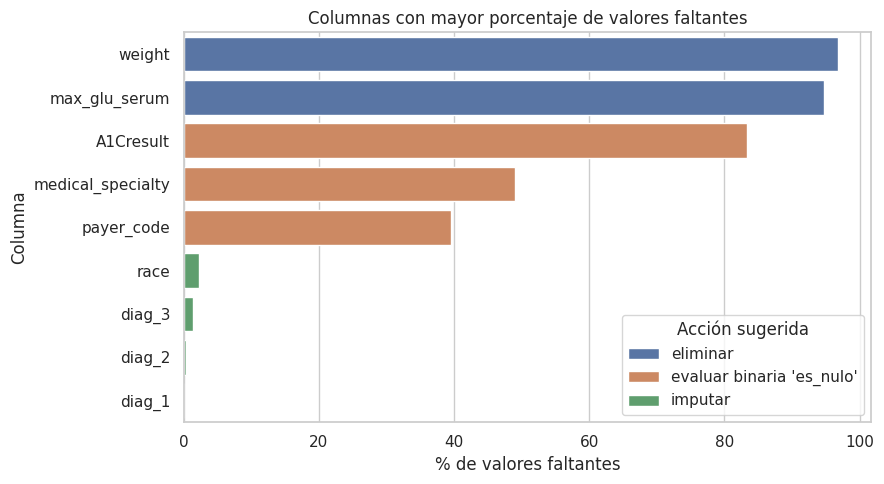

In [ ]:
top_missing = miss_report[miss_report["pct_faltante"] > 0].head(15)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=top_missing["pct_faltante"],
    y=top_missing.index,
    hue=top_missing["accion_sugerida"],
    dodge=False,
)
plt.xlabel("% de valores faltantes")
plt.ylabel("Columna")
plt.title("Columnas con mayor porcentaje de valores faltantes")
plt.legend(title="Acción sugerida", loc="lower right")
plt.tight_layout()
plt.show()


**Interpretación del gráfico:** cada barra es una columna, coloreada por la acción
que sugiere `quality.py` según el umbral de faltantes (>90% eliminar, 30-90% considerar
variable binaria "es_nulo", <30% imputar). Columnas como `weight` suelen aparecer con
faltantes muy altos (>95% en este dataset) — es la señal visual de que eliminarla es
razonable. Columnas con faltantes moderados (`payer_code`, `medical_specialty`) son
candidatas a convertirse en un indicador binario en vez de imputarse, porque el hecho de
que falte el dato puede ser informativo en sí mismo (no es aleatorio).


### 3.2 Duplicados y estructura por paciente

In [ ]:
dup_report = duplicate_report(df, key_columns=["encounter_id", "patient_nbr"])
dup_report


{'filas_totales': 101766,
 'filas_duplicadas_completas': 0,
 'encounter_id_valores_unicos': 101766,
 'encounter_id_max_repeticiones': 1,
 'encounter_id_pacientes_con_mas_de_1_encuentro': 0,
 'patient_nbr_valores_unicos': 71518,
 'patient_nbr_max_repeticiones': 40,
 'patient_nbr_pacientes_con_mas_de_1_encuentro': 16773}

**Por qué importa:** a diferencia de `encounter_id`, `patient_nbr` **no** debe ser
único — un mismo paciente puede tener varios encuentros hospitalarios. Lo relevante aquí
es `patient_nbr_pacientes_con_mas_de_1_encuentro`: si ese número es alto, el dataset
tiene dependencia entre filas (varias filas provienen del mismo paciente), lo que exige
un split train/test **agrupado por paciente** — de lo contrario habría fuga de
información (data leakage) entre entrenamiento y prueba.


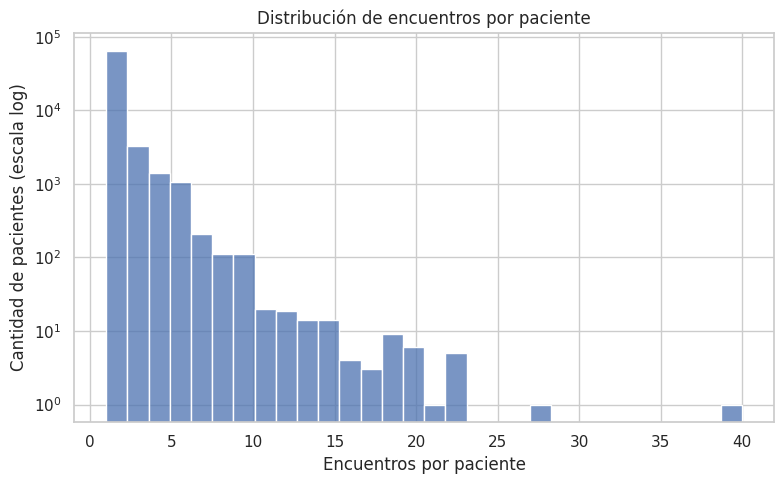

In [ ]:
encounters_per_patient = df["patient_nbr"].value_counts()

plt.figure(figsize=(8, 5))
sns.histplot(encounters_per_patient, bins=30)
plt.yscale("log")
plt.xlabel("Encuentros por paciente")
plt.ylabel("Cantidad de pacientes (escala log)")
plt.title("Distribución de encuentros por paciente")
plt.tight_layout()
plt.show()

**Interpretación:** la mayoría de los pacientes tiene un solo encuentro (barra alta
en 1), con una cola larga de pacientes con múltiples encuentros. El eje Y en escala
logarítmica es necesario porque de lo contrario la cola larga sería invisible junto a la
barra dominante en 1. Esta cola es exactamente la razón por la que el split debe agrupar
por `patient_nbr`.


### 3.3 Centinelas residuales y rangos numéricos imposibles

In [ ]:
sentinel_scan = sentinel_value_scan(df)
sentinel_scan


,columna,centinelas_encontrados
0,gender,{'Unknown/Invalid': 3}


Esta tabla es un chequeo doble: busca si algún valor centinela (`"?"`,
`"Unknown/Invalid"`, etc.) sobrevivió incluso después de la limpieza del loader. Si sale
vacía, la limpieza fue completa para las columnas tipo texto.


In [ ]:
rango_reglas = {
    "time_in_hospital": (1, 14),
    "num_lab_procedures": (0, 130),
    "num_procedures": (0, 6),
    "num_medications": (0, 90),
    "number_outpatient": (0, 50),
    "number_emergency": (0, 50),
    "number_inpatient": (0, 25),
    "number_diagnoses": (1, 16),
}

rango_report = numeric_out_of_range_report(df, rango_reglas)
rango_report


,columna,rango_esperado,min_real,max_real,filas_fuera_de_rango
0,time_in_hospital,"(1, 14)",1,14,0
1,num_lab_procedures,"(0, 130)",1,132,1
2,num_procedures,"(0, 6)",0,6,0
3,num_medications,"(0, 90)",1,81,0
4,number_outpatient,"(0, 50)",0,42,0
5,number_emergency,"(0, 50)",0,76,4
6,number_inpatient,"(0, 25)",0,21,0
7,number_diagnoses,"(1, 16)",1,16,0


**Cómo interpretarlo:** los rangos definidos arriba son los límites físicamente
razonables documentados para este dataset. Si `filas_fuera_de_rango` es 0 en todas las
filas, no hay valores imposibles; si aparece algún número mayor a 0, vale la pena
inspeccionar esas filas puntualmente antes de decidir si son errores de captura o casos
extremos legítimos.


## 4. Análisis univariado

Antes de comparar variables entre sí, se necesita entender la forma de cada una por
separado — esto determina, entre otras cosas, qué tests bivariados son válidos más
adelante (por ejemplo, distribuciones muy sesgadas favorecen tests no paramétricos).


In [ ]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

categorical_cols = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed",
]

df["readmitted_lt30"] = df["readmitted"] == "<30"


### 4.1 Variables numéricas

In [ ]:
num_summary = numeric_summary(df, numeric_cols)
num_summary


,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis
time_in_hospital,101766.0,4.395987,2.985108,1.0,1.0,2.0,4.0,6.0,14.0,14.0,1.133999,0.850251
num_lab_procedures,101766.0,43.095641,19.674362,1.0,1.0,31.0,44.0,57.0,85.0,132.0,-0.236544,-0.245074
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,0.0,1.0,2.0,6.0,6.0,1.316415,0.857110
num_medications,101766.0,16.021844,8.127566,1.0,3.0,10.0,15.0,20.0,43.0,81.0,1.326672,3.468155
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,0.0,5.0,42.0,8.832959,147.907736
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,0.0,3.0,76.0,22.855582,1191.686726
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,0.0,1.0,6.0,21.0,3.614139,20.719397
number_diagnoses,101766.0,7.422607,1.933600,1.0,2.0,6.0,8.0,9.0,9.0,16.0,-0.876746,-0.079056


**Interpretación de `skew` y `kurtosis`:** un `skew` cercano a 0 indica una
distribución simétrica; valores positivos altos (frecuentes en `number_emergency` o
`number_inpatient`, que son conteos con muchos ceros) indican una cola larga hacia la
derecha. `kurtosis` alta indica una distribución más "puntiaguda" con colas más pesadas
que una normal — es decir, más valores extremos de lo esperado. Estos dos números son
justamente lo que confirman visualmente los histogramas de abajo, y son la razón por la
que el análisis bivariado usa Mann-Whitney (no paramétrico) en vez de un t-test.


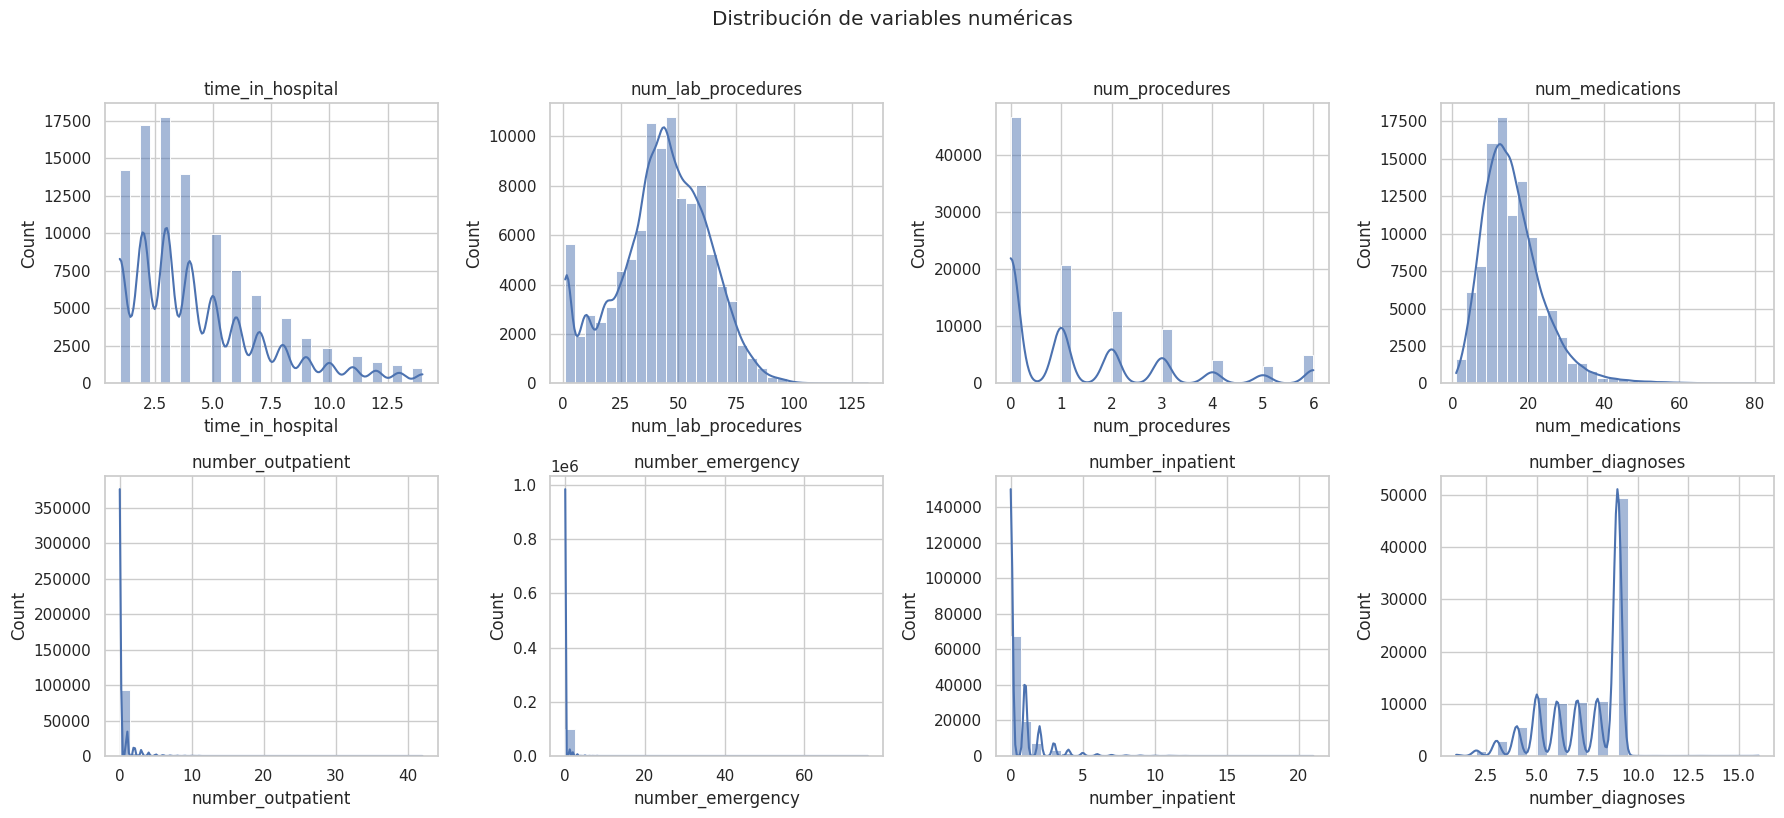

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle("Distribución de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()


**Cómo leerlos:** columnas como `number_emergency`, `number_outpatient` o
`number_inpatient` deberían mostrar una barra dominante en 0 y una cola larga hacia la
derecha (muchos pacientes sin visitas previas de ese tipo, pocos con varias) — esto
confirma el `skew` positivo alto calculado arriba. `time_in_hospital` y
`num_medications` suelen verse más cercanas a una forma acampanada, aunque igual con
algo de asimetría.


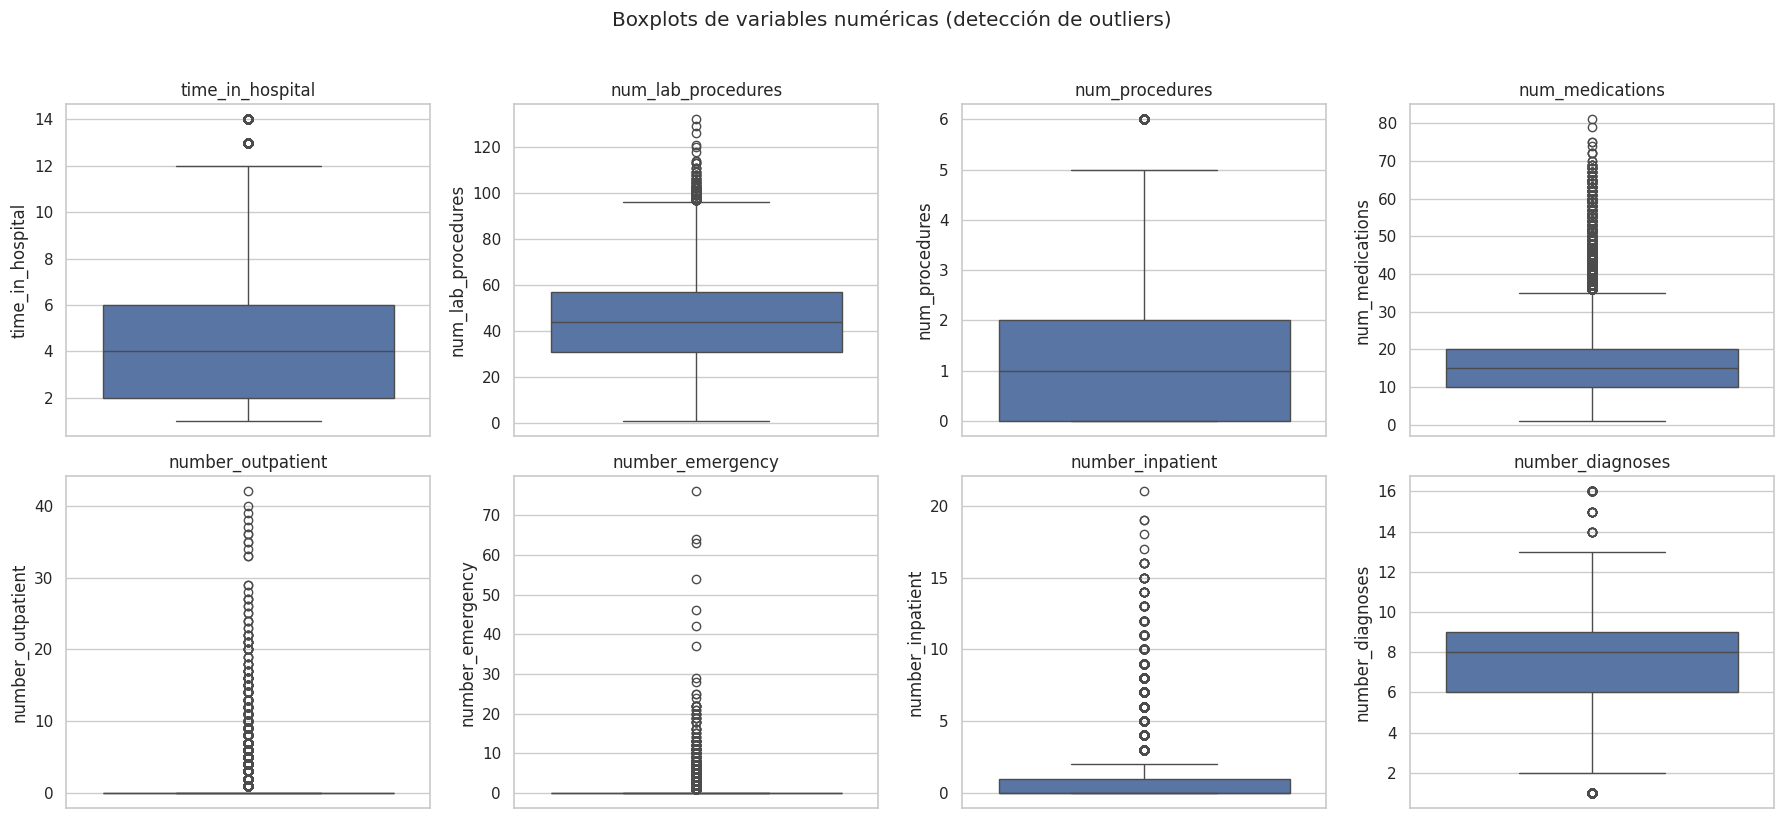

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle("Boxplots de variables numéricas (detección de outliers)", y=1.02)
plt.tight_layout()
plt.show()


**Cómo leerlos:** la caja representa el rango intercuartílico (percentil 25 a 75) y
la línea central la mediana. Muchos puntos individuales por fuera de los bigotes
confirman visualmente lo que el `skew` numérico ya sugería: distribuciones con outliers
en el extremo superior. Esto es exactamente lo que justifica usar Spearman en vez de
Pearson en la matriz de correlación — Pearson es sensible a estos outliers, Spearman
(basado en rangos) es robusto a ellos.


### 4.2 Variables categóricas

In [ ]:
cat_summary = categorical_summary(df, categorical_cols)
cat_summary


,columna,cardinalidad,top_categorias
0,race,5,"{'Caucasian': 0.748, 'AfricanAmerican': 0.189,..."
1,gender,3,"{'Female': 0.538, 'Male': 0.462, 'Unknown/Inva..."
2,age,10,"{'[70-80)': 0.256, '[60-70)': 0.221, '[50-60)'..."
3,admission_type_id,8,"{1: 0.531, 3: 0.185, 2: 0.182, 6: 0.052, 5: 0...."
4,discharge_disposition_id,26,"{1: 0.592, 3: 0.137, 6: 0.127, 18: 0.036, 2: 0..."
5,admission_source_id,17,"{7: 0.565, 1: 0.291, 17: 0.067, 4: 0.031, 6: 0..."
6,max_glu_serum,3,"{nan: 0.947, 'Norm': 0.026, '>200': 0.015, '>3..."
7,A1Cresult,3,"{nan: 0.833, '>8': 0.081, 'Norm': 0.049, '>7':..."
8,insulin,4,"{'No': 0.466, 'Steady': 0.303, 'Down': 0.12, '..."
9,change,2,"{'No': 0.538, 'Ch': 0.462}"


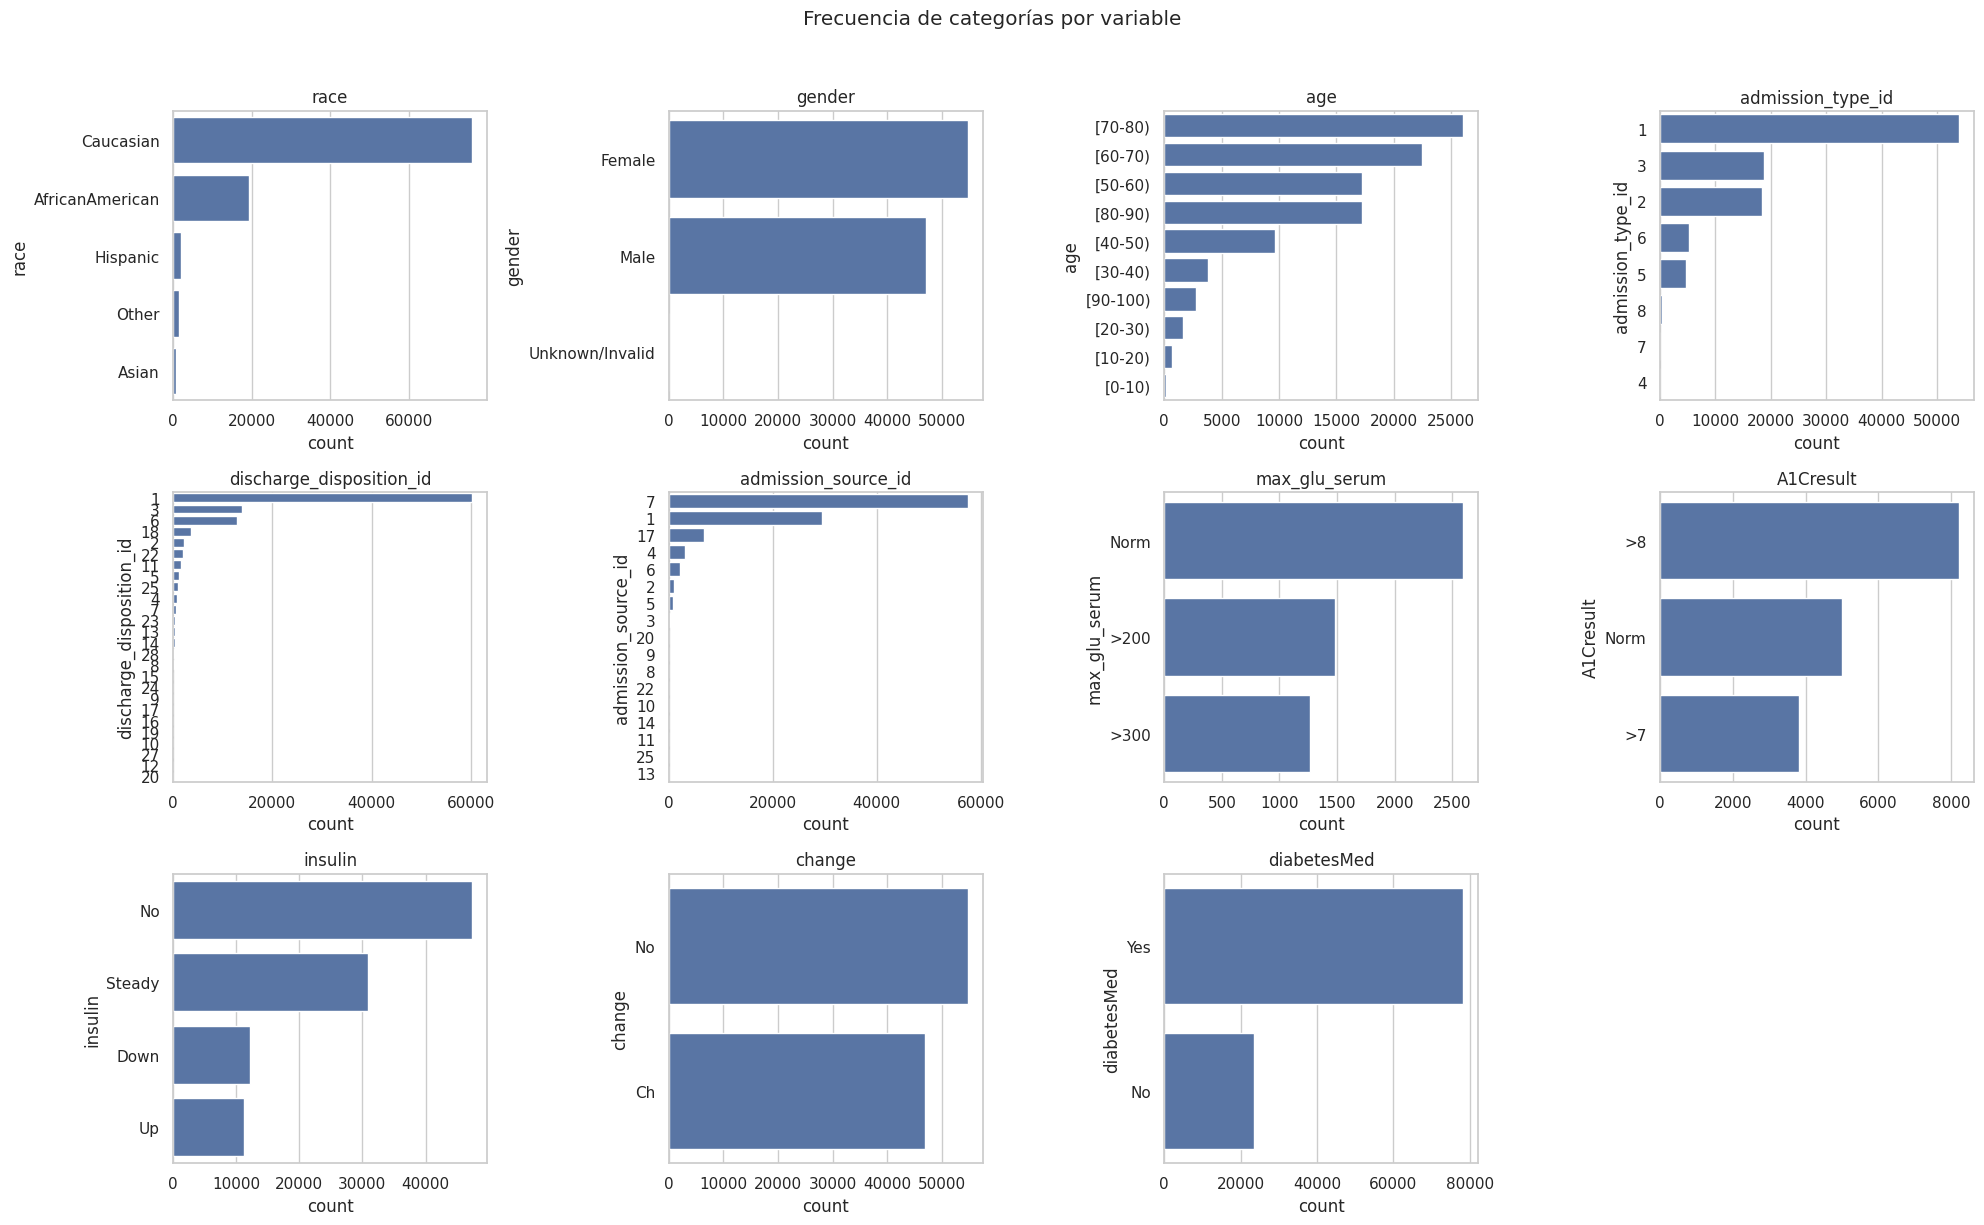

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flat, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(categorical_cols):]:
    ax.axis("off")
plt.suptitle("Frecuencia de categorías por variable", y=1.02)
plt.tight_layout()
plt.show()


**Cómo interpretarlo:** una barra que domina ampliamente sobre las demás (por
ejemplo, en `race` suele predominar `Caucasian`, o en `max_glu_serum` predomina `None`)
indica baja variabilidad efectiva en esa columna — con una categoría muy dominante, el
poder estadístico para detectar asociación con el target se reduce. Columnas con muchas
barras pequeñas (alta cardinalidad) son las que más fácilmente violan el supuesto de
conteos esperados mínimos del test chi-cuadrado que se usa más adelante.


### 4.3 Distribución del target

In [ ]:
target_dist = target_distribution(df, target_col="readmitted")
target_dist


proporcion
original NO                       0.5391
         >30                      0.3493
         <30                      0.1116
binario  resto                    0.8884
         readmitido <30 días      0.1116

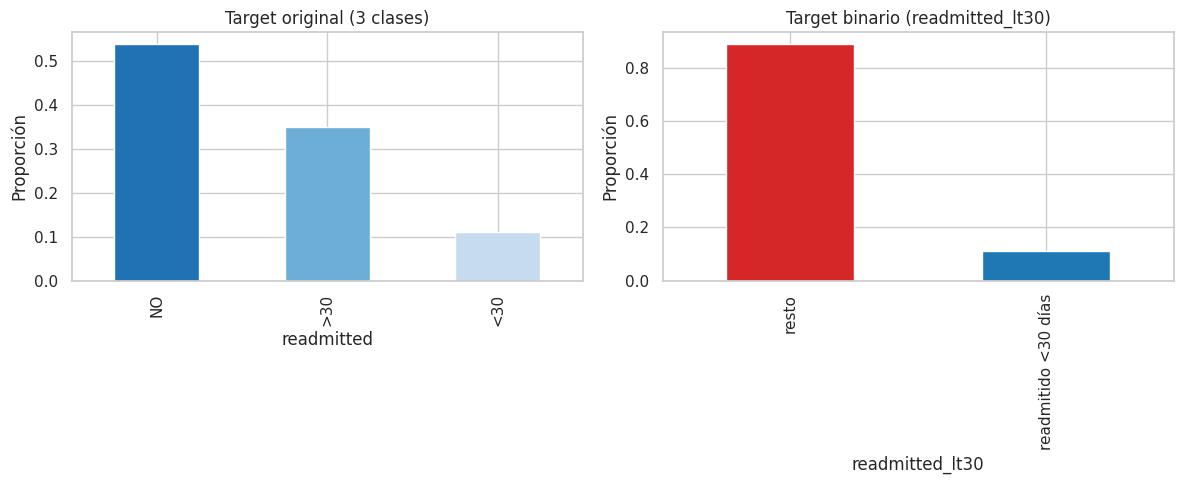

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["readmitted"].value_counts(normalize=True).plot(
    kind="bar", ax=axes[0], color=sns.color_palette("Blues_r", 3)
)
axes[0].set_title("Target original (3 clases)")
axes[0].set_ylabel("Proporción")

df["readmitted_lt30"].map({True: "readmitido <30 días", False: "resto"}).value_counts(
    normalize=True
).plot(kind="bar", ax=axes[1], color=["#d62728", "#1f77b4"])
axes[1].set_title("Target binario (readmitted_lt30)")
axes[1].set_ylabel("Proporción")

plt.tight_layout()
plt.show()


**Esta es la gráfica más importante de todo el EDA para el modelado posterior.** La
clase `<30 días` suele representar solo ~11% de los casos en este dataset — un
desbalance de clases considerable. La barra visiblemente más corta es la evidencia
directa de que:

- **Accuracy no sirve como métrica** de evaluación del modelo (un clasificador que
  siempre predice "no readmitido" tendría ~89% de accuracy sin ser útil).
- Conviene usar **AUC-PR, F1 o recall de la clase minoritaria** en su lugar.
- Se debe considerar **class weights** o técnicas de resampling (SMOTE, undersampling)
  al entrenar el modelo.


## 5. Análisis bivariado

Aquí se cruza cada variable contra el target o entre sí, para identificar señal
predictiva y redundancia.


### 5.1 Correlación entre variables numéricas

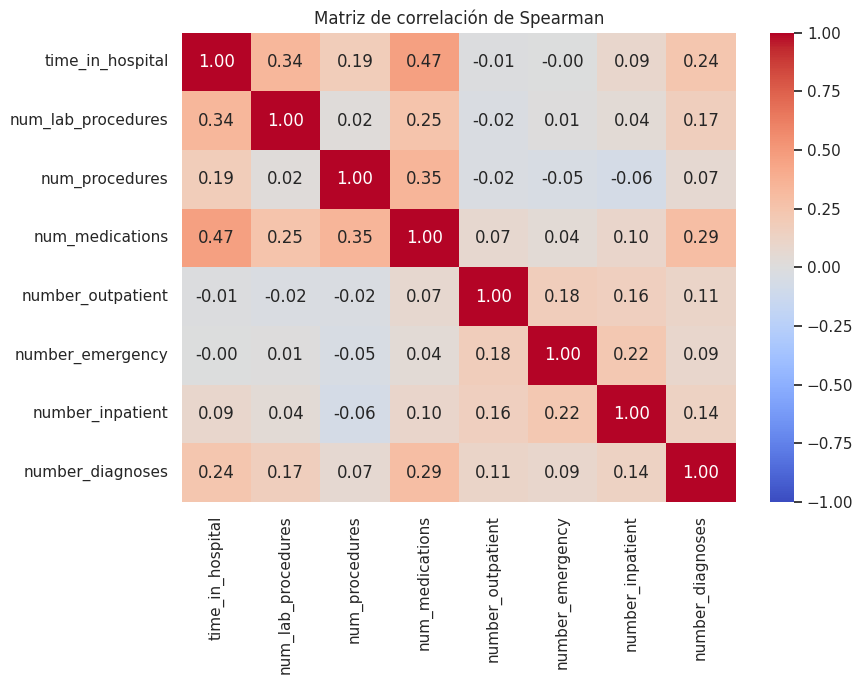

In [ ]:
corr = correlation_matrix(df, numeric_cols, method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()


In [ ]:
high_corr = high_correlation_pairs(corr, threshold=0.8)
high_corr


,variable_1,variable_2,correlacion


**Por qué Spearman y no Pearson:** ya se estableció en el análisis univariado que
varias de estas columnas están sesgadas y con outliers; Spearman mide relación monótona
basada en rangos, por lo que no se distorsiona por esos outliers como sí lo haría
Pearson.

**Cómo leer el heatmap:** colores intensos rojos (correlación positiva fuerte) o azules
(negativa fuerte) fuera de la diagonal señalan pares candidatos a redundancia. El
heatmap es más útil que la tabla de pares para detectar **bloques** de variables
correlacionadas entre sí — algo que una lista plana de pares no deja ver tan fácilmente.
Si `high_correlation_pairs` devuelve una tabla vacía, no hay pares por encima del umbral
de 0.8, lo cual es razonable en este dataset dado que la mayoría de estas variables
miden aspectos distintos de la atención (procedimientos, medicamentos, visitas previas).


### 5.2 Variables categóricas vs. target (chi-cuadrado)

In [ ]:
chi2_results = categorical_vs_target_chi2(df, target_col="readmitted")
chi2_results


,variable,chi2,p_value,dof
6,diag_1,4966.473536,0.000000e+00,1430
7,diag_2,3969.051778,2.970695e-223,1494
8,diag_3,3781.584269,4.000059e-182,1576
5,medical_specialty,1218.767114,1.840428e-170,142
26,insulin,516.695761,2.126586e-108,6
4,payer_code,507.430868,6.135414e-87,32
33,diabetesMed,386.510884,1.175514e-84,2
2,age,313.171753,9.348415e-56,18
32,change,215.825001,1.362061e-47,2
11,metformin,104.841777,2.445917e-20,6


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


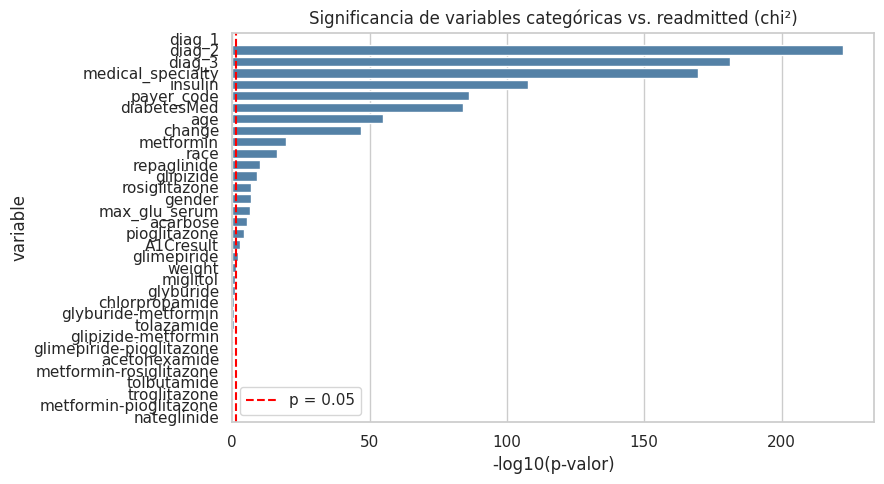

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(
    x=-np.log10(chi2_results["p_value"]),
    y=chi2_results["variable"],
    color="steelblue",
)
plt.axvline(-np.log10(0.05), color="red", linestyle="--", label="p = 0.05")
plt.xlabel("-log10(p-valor)")
plt.title("Significancia de variables categóricas vs. readmitted (chi²)")
plt.legend()
plt.tight_layout()
plt.show()


**Cómo interpretar el p-valor:** un p-valor bajo (a la derecha de la línea roja)
sugiere que la variable no es independiente del target — hay asociación estadísticamente
detectable. **Esto no mide qué tan fuerte es esa asociación**, solo si es
estadísticamente distinguible de cero. Con ~100,000 filas, hasta asociaciones muy
pequeñas se vuelven "significativas" — por eso el ranking de relevancia (sección 6) es
más útil para decidir qué variables priorizar en el modelo.

**Advertencia:** columnas de alta cardinalidad (muchas categorías, como `diag_1`) pueden
tener celdas esperadas muy pequeñas en la tabla de contingencia, lo que hace que el
p-valor del chi² sea menos confiable — hay que tratar esos resultados con cautela.

**Sobre comparaciones múltiples:** se está corriendo un test por cada variable
categórica. Con un umbral ingenuo de 0.05, el número esperado de falsos positivos crece
con la cantidad de tests realizados — vale la pena considerar una corrección (FDR /
Benjamini-Hochberg) si estos p-valores se van a usar para decidir inclusión de variables
en el modelo final.


### 5.3 Variables numéricas vs. target binario (Mann-Whitney)

In [ ]:
mw_results = numeric_vs_target_test(df, numeric_cols, "readmitted_lt30")
mw_results


,columna,mediana_readmitido_lt30,mediana_resto,p_valor
6,number_inpatient,0.0,0.0,0.000000e+00
5,number_emergency,0.0,0.0,4.613076e-91
0,time_in_hospital,4.0,4.0,2.689648e-59
7,number_diagnoses,9.0,8.0,2.677772e-51
3,num_medications,16.0,15.0,1.394205e-47
4,number_outpatient,0.0,0.0,1.151406e-27
1,num_lab_procedures,45.0,44.0,5.376925e-11
2,num_procedures,1.0,1.0,5.115273e-02


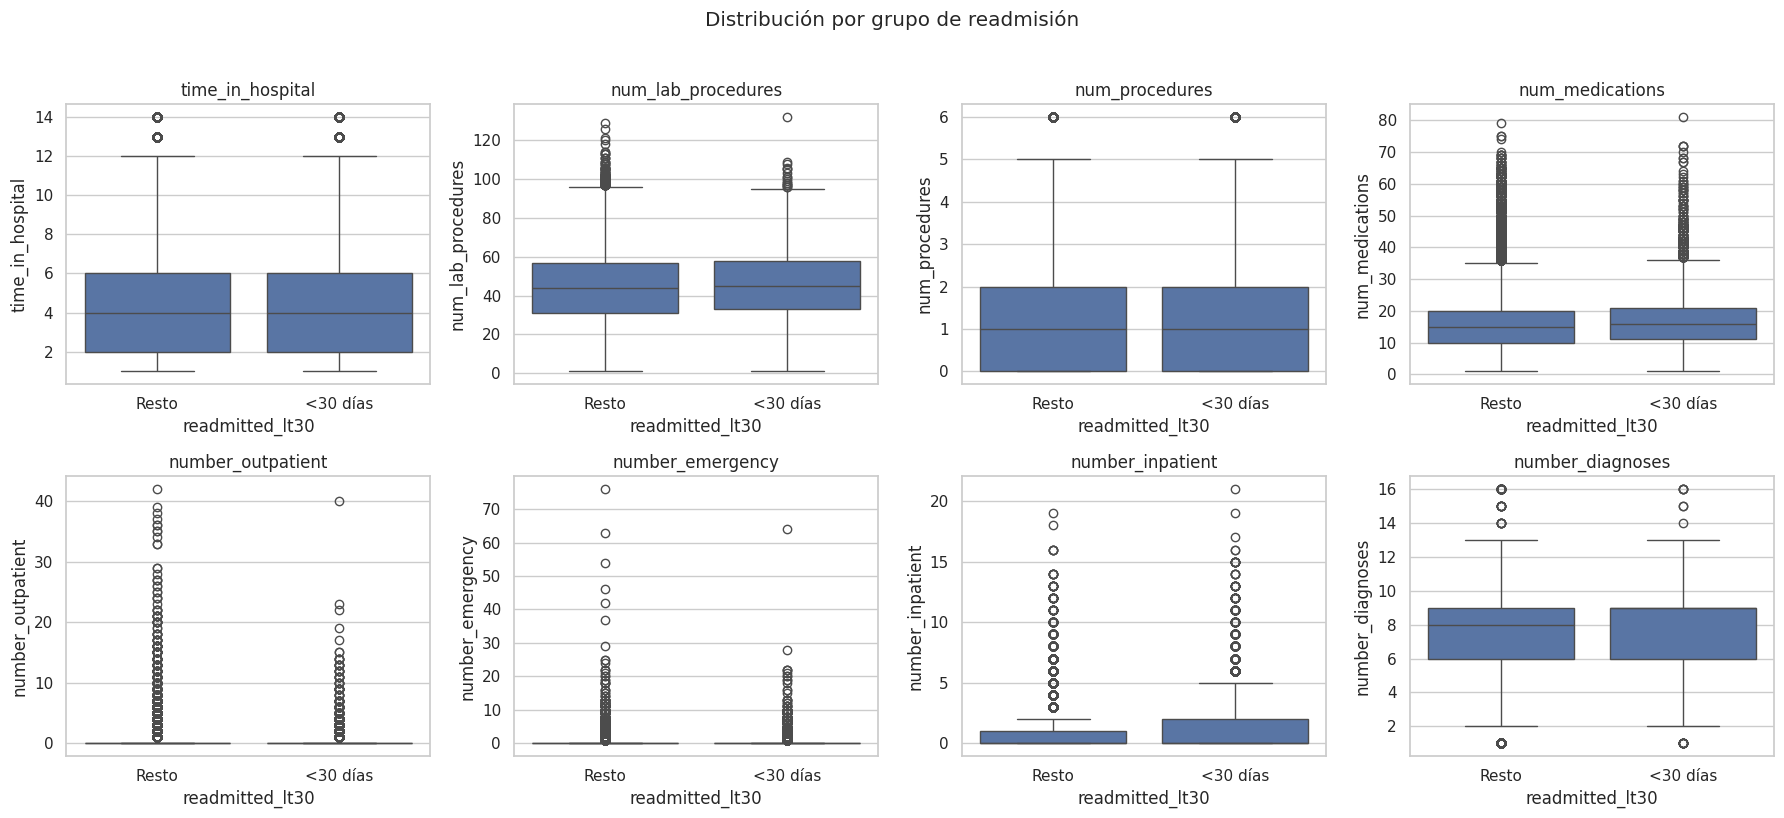

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(x=df["readmitted_lt30"], y=df[col], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Resto", "<30 días"])
    ax.set_title(col)
plt.suptitle("Distribución por grupo de readmisión", y=1.02)
plt.tight_layout()
plt.show()

**Por qué Mann-Whitney y no un t-test:** el t-test asume distribuciones
aproximadamente normales; ya se vio en el análisis univariado que estas variables no lo
son. Mann-Whitney compara si una distribución tiende a tomar valores más altos que la
otra basándose en rangos, sin asumir normalidad — por eso el código reporta **medianas**
por grupo y no medias, que es justamente el estadístico que este test realmente evalúa.

**Cómo leer los boxplots:** si la mediana (línea dentro de la caja) del grupo `<30 días`
está visiblemente desplazada respecto al grupo `resto`, es la confirmación visual de un
p-valor bajo en la tabla de arriba. Variables como `number_inpatient` o
`number_emergency` suelen mostrar esta diferencia de forma más marcada que variables como
`num_lab_procedures`.


## 6. Ranking de relevancia

Los tests anteriores dicen si hay asociación (o no) y en qué dirección, pero no dan una
magnitud fácilmente comparable entre variables de distinta naturaleza. Esta sección
resuelve eso.


### 6.1 Mutual information (numéricas)

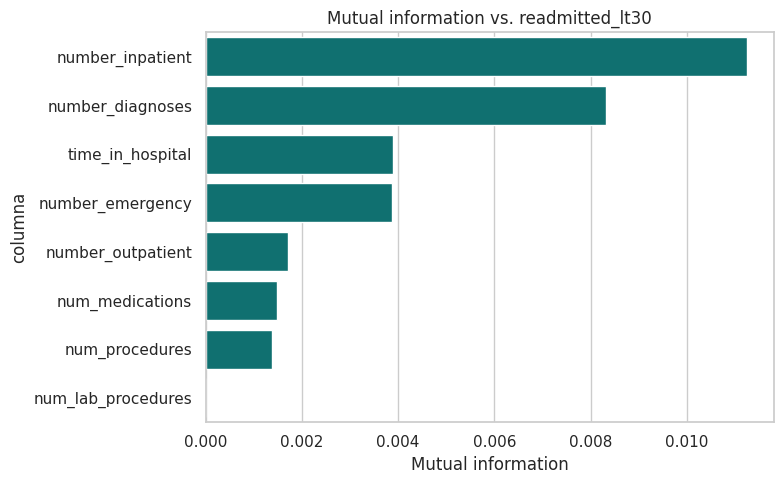

In [ ]:
mi_ranking = mutual_info_ranking(df, numeric_cols, "readmitted_lt30")

plt.figure(figsize=(8, 5))
sns.barplot(x=mi_ranking["mutual_info"], y=mi_ranking["columna"], color="teal")
plt.title("Mutual information vs. readmitted_lt30")
plt.xlabel("Mutual information")
plt.tight_layout()
plt.show()


**Por qué mutual information y no solo Spearman/Mann-Whitney:** los tests
anteriores asumen relaciones monótonas o de orden. La información mutua no asume ninguna
forma funcional — captura relaciones no lineales (por ejemplo, en forma de U) que
Spearman podría pasar por alto. Es un complemento, no un reemplazo: una variable puede
tener MI alta y correlación de Spearman baja si la relación con el target no es
monótona.

**Cómo leer el gráfico:** ordenado de mayor a menor, un "codo" visible (una caída
brusca entre una barra y la siguiente) sugiere un punto de corte natural entre variables
con señal real y variables que aportan poco más que ruido para el modelo.


### 6.2 Cramér's V (categóricas)

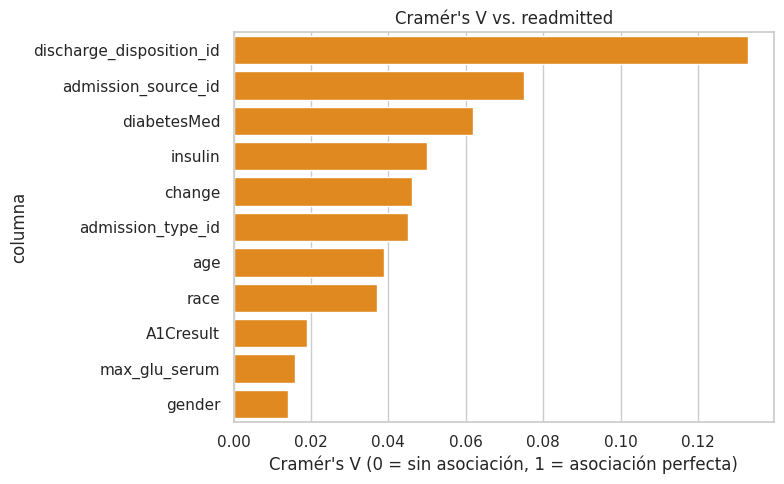

In [ ]:
cv_ranking = cramers_v_ranking(df, categorical_cols, "readmitted")

plt.figure(figsize=(8, 5))
sns.barplot(x=cv_ranking["cramers_v"], y=cv_ranking["columna"], color="darkorange")
plt.title("Cramér's V vs. readmitted")
plt.xlabel("Cramér's V (0 = sin asociación, 1 = asociación perfecta)")
plt.tight_layout()
plt.show()


**Por qué Cramér's V y no solo el chi²:** la magnitud del estadístico chi² depende
del tamaño de muestra — con n grande, hasta asociaciones triviales dan chi² alto. Cramér's V
normaliza ese estadístico a una escala de 0 a 1, comparable entre variables sin importar
su número de categorías o el tamaño de la muestra. Por eso el chi² se usa para decidir
significancia (sección 5.2) y Cramér's V para *jerarquizar* qué tan fuerte es esa
asociación (esta sección).

**Advertencia general para toda esta sección:** un valor alto de mutual information o
Cramér's V indica asociación, no causalidad. Una variable como
`discharge_disposition_id` puede correlacionar con el reingreso simplemente porque
ambas están relacionadas con la severidad de la enfermedad (un confusor), no porque el
tipo de alta *cause* el reingreso.


## 7. Conclusiones del EDA

- Este dataset no tiene grupo de control sin diabetes: las 101,766 filas son encuentros hospitalarios de pacientes ya diagnosticados con diabetes.
- El grupo [70-80) es el grupo más frecuente, seguido de [60-70), [50-60] y [80-90), estos cuatro rangos concentran la mayoría de la muestra. Esto es coherente ya que la epidemiología típica de la diabetes tipo 2 suele aparecer y se complica en adultos mayores.
- La mayoría de pacientes llega por urgencias. Más de la mitad de los diabeticos son hospitalizados cuando la enfermedad se descompensó, no por seguimiento médico.
- El 77% de los pacientes recibe medicación para la diabetes, el 46.2% de los encuentros hubo un cambio de meidcación. El grupo de mayor riesgo es el que requiere ajustes de insulina.
- El control glucémico no se mide con regularidad, pero predice mucho. En los pocos casos donde sí se midió, la categoría más común es >8 (mal control), por encima de normal o >7. Esta es la etiqueta que más refleja una sospecha de descompensación clínica.
- El paciente que más probabilidad tiene de reingresar en <30 días no se define por edad, raza o género, sino por historial de hospitalizaciones previas y múltiples diagnósticos simultáneos.

